<a href="https://colab.research.google.com/github/oksanayefimova/AES_repo/blob/dev_icnale_research/Fairness_of_Scorring_System_ICNALE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fairness of Scorring System: ICNALE

## Data Parsing

In [1]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. ICNALE Participant Background Survey Sheet

In [2]:
import pandas as pd
file_path = '/content/drive/MyDrive/AES_data/ICNALE_Survey_202603.xlsx'
xls = pd.ExcelFile(file_path)
print("Sheet names:", xls.sheet_names)
participants = pd.read_excel(file_path, sheet_name=xls.sheet_names[1])

Sheet names: ['Info Type', 'Participants']


In [3]:
participants

,Module,Code,Country,L1,PTJ1 (wds),PTJ2 (wds),SMK1 (wds),SMK2 (wds),Self Evaluation,Sex,...,"Listening (Amount of Studying ""Listening"")","Reading (Amount of Studying ""Reading"")","Speaking (Amount of Studying ""Speaking"")","Writing (Amount of Studying ""Writing"")",NS (Amount of Learning from NS Teachers),Pronunciation (Amount of Learning Pronunciation),Presentation (Amount of Learning Eng Presentations),EssayW (Amount of Learning Essay Writing),Like to talk in L1 (Attitude),Like to talk in L2 (Attitude)
0,SD,SD_CHN_001,China,Chinese,NaN,NaN,NaN,NaN,NaN,M,...,4.25,4.50,3.00,4.75,NaN,NaN,NaN,NaN,6.0,3.0
1,SD,SD_CHN_002,China,Chinese,NaN,NaN,NaN,NaN,NaN,M,...,3.75,3.50,3.25,3.50,NaN,NaN,NaN,NaN,6.0,4.0
2,SD,SD_CHN_003,China,Chinese,NaN,NaN,NaN,NaN,NaN,F,...,2.50,3.25,1.50,2.25,NaN,NaN,NaN,NaN,6.0,4.0
3,SD,SD_CHN_004,China,Chinese,NaN,NaN,NaN,NaN,NaN,M,...,3.25,2.50,1.25,1.50,NaN,NaN,NaN,NaN,6.0,3.0
4,SD,SD_CHN_005,China,Chinese,NaN,NaN,NaN,NaN,NaN,F,...,2.25,2.00,2.25,2.00,NaN,NaN,NaN,NaN,6.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5490,WEP,WEP_VNM_434,Vietnam,Vietnamese,NaN,NaN,NaN,NaN,NaN,F,...,5.25,4.75,4.25,4.50,6,6,6,6,NaN,NaN
5491,WEP,WEP_VNM_435,Vietnam,Vietnamese,NaN,NaN,NaN,NaN,NaN,M,...,3.50,3.25,4.00,3.50,5,5,5,5,NaN,NaN
5492,WEP,WEP_VNM_436,Vietnam,Vietnamese,NaN,NaN,NaN,NaN,NaN,F,...,4.50,4.25,4.25,4.50,1,6,6,5,NaN,NaN
5493,WEP,WEP_VNM_437,Vietnam,Vietnamese,NaN,NaN,NaN,NaN,NaN,F,...,6.00,4.00,3.75,3.50,6,4,5,5,NaN,NaN


In [4]:
participants.Module.unique()

array(['SD', 'SM', 'WE', 'WEP'], dtype=object)

i think we need only Module = WE

### 2. Essays (from Written essays WE)

In [5]:
WE_FOLDER_PATH = '/content/drive/MyDrive/AES_data/ICNALE_WE_2.6/WE_0_Unclassified_Unmerged'
data = []

# for each essay in the dir
for filename in os.listdir(WE_FOLDER_PATH):
    if filename.endswith(".txt"):
        name_without_ext = filename.replace('.txt', '')
        parts = name_without_ext.split('_')

        # read the file name structure
        if len(parts) >= 5:
            module = parts[0]    # WE
            region = parts[1]    # CHN
            task = parts[2]      # PTJ0
            student_id = parts[3] # 001
            cefr = "_".join(parts[4:]) # B1_1

            # read essay text
            file_path = os.path.join(WE_FOLDER_PATH, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                text = f.read().strip()

            data.append({
                'filename': name_without_ext,
                'region': region,
                'task': task,
                'student_id': student_id,
                'cefr_level': cefr,
                'orig_essay_text': text
            })

df_essays = pd.DataFrame(data)
df_essays.head()

,filename,region,task,student_id,cefr_level,orig_essay_text
0,WE_TWN_SMK0_035_B1_1,TWN,SMK0,035,B1_1,﻿About smoking should be completely banned at ...
1,WE_TWN_SMK0_048_B2_0,TWN,SMK0,048,B2_0,"﻿My answer is ""YES. "" Smoking should be comple..."
2,WE_TWN_SMK0_069_B2_0,TWN,SMK0,069,B2_0,﻿I disagree on the idea that smoking should be...
3,WE_TWN_SMK0_064_B1_1,TWN,SMK0,064,B1_1,﻿I think it will be pleasure for many people i...
4,WE_TWN_SMK0_066_B1_2,TWN,SMK0,066,B1_2,﻿Smoking has been generally viewed as a seriou...


In [6]:
df_essays

,filename,region,task,student_id,cefr_level,orig_essay_text
0,WE_TWN_SMK0_035_B1_1,TWN,SMK0,035,B1_1,﻿About smoking should be completely banned at ...
1,WE_TWN_SMK0_048_B2_0,TWN,SMK0,048,B2_0,"﻿My answer is ""YES. "" Smoking should be comple..."
2,WE_TWN_SMK0_069_B2_0,TWN,SMK0,069,B2_0,﻿I disagree on the idea that smoking should be...
3,WE_TWN_SMK0_064_B1_1,TWN,SMK0,064,B1_1,﻿I think it will be pleasure for many people i...
4,WE_TWN_SMK0_066_B1_2,TWN,SMK0,066,B1_2,﻿Smoking has been generally viewed as a seriou...
...,...,...,...,...,...,...
5595,WE_CHN_SMK0_068_B1_1,CHN,SMK0,068,B1_1,﻿I don't suppose that it's a wise idea to ban ...
5596,WE_CHN_SMK0_074_B1_2,CHN,SMK0,074,B1_2,"﻿As is known to all, cigarette is popular for ..."
5597,WE_CHN_SMK0_062_B1_1,CHN,SMK0,062,B1_1,﻿I think that smoking should be completely ban...
5598,WE_CHN_SMK0_061_A2_0,CHN,SMK0,061,A2_0,﻿Today cigarettes exist everywhere. People can...


In [7]:
df_essays

,filename,region,task,student_id,cefr_level,orig_essay_text
0,WE_TWN_SMK0_035_B1_1,TWN,SMK0,035,B1_1,﻿About smoking should be completely banned at ...
1,WE_TWN_SMK0_048_B2_0,TWN,SMK0,048,B2_0,"﻿My answer is ""YES. "" Smoking should be comple..."
2,WE_TWN_SMK0_069_B2_0,TWN,SMK0,069,B2_0,﻿I disagree on the idea that smoking should be...
3,WE_TWN_SMK0_064_B1_1,TWN,SMK0,064,B1_1,﻿I think it will be pleasure for many people i...
4,WE_TWN_SMK0_066_B1_2,TWN,SMK0,066,B1_2,﻿Smoking has been generally viewed as a seriou...
...,...,...,...,...,...,...
5595,WE_CHN_SMK0_068_B1_1,CHN,SMK0,068,B1_1,﻿I don't suppose that it's a wise idea to ban ...
5596,WE_CHN_SMK0_074_B1_2,CHN,SMK0,074,B1_2,"﻿As is known to all, cigarette is popular for ..."
5597,WE_CHN_SMK0_062_B1_1,CHN,SMK0,062,B1_1,﻿I think that smoking should be completely ban...
5598,WE_CHN_SMK0_061_A2_0,CHN,SMK0,061,A2_0,﻿Today cigarettes exist everywhere. People can...


### Scores (From Edited Essays EE)

In [8]:
import pandas as pd
file_path = '/content/drive/MyDrive/AES_data/ICNALE_EE_3.1/ICNALE_EE_3.1/ICNALE EE Infosheet.xlsx'
xls = pd.ExcelFile(file_path)
print("Sheet names:", xls.sheet_names)


Sheet names: ['Sheet1']


In [9]:
# columns_to_keep = [
#     'WEriter Code',
#     'Content (/12)',
#     'Organization (/12)',
#     'Vocabulary (/12)',
#     'Language Use (/12)',
#     'Mechanics (/12)',
#     'Total 1 (%)',
#     'Total 2 (Weighted %)'
# ]

scores = pd.read_excel(file_path, sheet_name=xls.sheet_names[0], header=1)
scores = scores.rename(columns={'WEriter Code': 'student_id'})
scores

,student_id,Sex,Age,Grade/Degree,Yrs of Stay (< Yrs),Major,Acad. Genre,Prof. Test,Score,Vocab Size Test,...,Total 2 (Weighted %),File Name,Country,Topic,Learners' Prof.,Editor,Tokens.1,A (Added),D (Deleted),A+D
0,WE_CHN_001,F,20,2.0,NaN,Law,Social Sciences,CEE,72,30,...,68.3,EE_CHN_PTJ0_001_B1_1_EDIT,CHN,PTJ,B1_1,LC,275,34,29,63
1,WE_CHN_002,F,21,3.0,NaN,Law,Social Sciences,CEE,77,27,...,62.1,EE_CHN_PTJ0_002_B1_1_EDIT,CHN,PTJ,B1_1,LC,210,18,13,31
2,WE_CHN_003,F,20,3.0,NaN,Law,Social Sciences,CEE,79,32,...,73.8,EE_CHN_PTJ0_003_B1_1_EDIT,CHN,PTJ,B1_1,LC,255,29,17,46
3,WE_CHN_004,F,20,2.0,NaN,Chemistry,Sciences & Technology,CEE,87,37,...,62.1,EE_CHN_PTJ0_004_B1_2_EDIT,CHN,PTJ,B1_2,LC,267,27,25,52
4,WE_CHN_005,M,20,2.0,NaN,Chemistry,Sciences & Technology,CEE,84,44,...,70.8,EE_CHN_PTJ0_005_B1_2_EDIT,CHN,PTJ,B1_2,LC,228,27,26,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,WE_PHL_085,F,17,2.0,NaN,Finance,Social Sciences,NaN,NaN,34,...,59.6,EE_PHL_SMK0_085_B1_1_EDIT,PHL,SMK,B1_1,HAC,195,45,34,79
636,WE_PHL_113,F,18,3.0,NaN,Preschool Education,Humanities,NaN,NaN,28,...,32.5,EE_PHL_SMK0_113_B1_1_EDIT,PHL,SMK,B1_1,HAC,194,41,40,81
637,WE_PHL_114,M,19,1.0,NaN,Finance,Social Sciences,NaN,NaN,32,...,69.6,EE_PHL_SMK0_114_B1_1_EDIT,PHL,SMK,B1_1,HAC,221,52,40,92
638,WE_PHL_123,F,18,2.0,NaN,English,Humanities,NaN,NaN,34,...,56.7,EE_PHL_SMK0_123_B1_1_EDIT,PHL,SMK,B1_1,HAC,218,62,53,115


In [10]:
scores.columns

Index(['student_id', 'Sex', 'Age', 'Grade/Degree', 'Yrs of Stay (< Yrs)',
       'Major', 'Acad. Genre', 'Prof. Test', 'Score', 'Vocab Size Test',
       'CEFR', 'INTM', 'INSM', 'INTM+INSM', 'INTM-INSM', 'Primary',
       'Secondary', 'College', 'Inschool', 'Outschool', 'Listening', 'Reading',
       'Speaking', 'Writing', 'NS', 'Pronunciation', 'Presentation', 'EssayW',
       'Tokens', 'Content (/12)', 'Organization (/12)', 'Vocabulary (/12)',
       'Language Use (/12)', 'Mechanics (/12)', 'Total 1 (%)',
       'Total 2 (Weighted %)', 'File Name', 'Country', 'Topic',
       'Learners' Prof.', 'Editor', 'Tokens.1', 'A (Added)', 'D (Deleted)',
       'A+D'],
      dtype='object')

## Data Cleaning and Merging

In [11]:
scores['student_id'].nunique()

320

In [34]:
scores["filename"] = scores["File Name"].str.replace(r"^EE_", "WE_", regex=True)
scores["filename"] = scores["filename"].str.replace(r"_EDIT$", "", regex=True)
scores['filename'] = scores['filename'].str.replace('TEEN', 'TWN', regex=False)
scores['student_id'] = scores['student_id'].str.replace('TWEN', 'TWN', regex=False)

In [35]:
scores.head()

,student_id,Sex,Age,Grade/Degree,Yrs of Stay (< Yrs),Major,Acad. Genre,Prof. Test,Score,Vocab Size Test,...,File Name,Country,Topic,Learners' Prof.,Editor,Tokens.1,A (Added),D (Deleted),A+D,filename
0,WE_CHN_001,F,20,2.0,NaN,Law,Social Sciences,CEE,72,30,...,EE_CHN_PTJ0_001_B1_1_EDIT,CHN,PTJ,B1_1,LC,275,34,29,63,WE_CHN_PTJ0_001_B1_1
1,WE_CHN_002,F,21,3.0,NaN,Law,Social Sciences,CEE,77,27,...,EE_CHN_PTJ0_002_B1_1_EDIT,CHN,PTJ,B1_1,LC,210,18,13,31,WE_CHN_PTJ0_002_B1_1
2,WE_CHN_003,F,20,3.0,NaN,Law,Social Sciences,CEE,79,32,...,EE_CHN_PTJ0_003_B1_1_EDIT,CHN,PTJ,B1_1,LC,255,29,17,46,WE_CHN_PTJ0_003_B1_1
3,WE_CHN_004,F,20,2.0,NaN,Chemistry,Sciences & Technology,CEE,87,37,...,EE_CHN_PTJ0_004_B1_2_EDIT,CHN,PTJ,B1_2,LC,267,27,25,52,WE_CHN_PTJ0_004_B1_2
4,WE_CHN_005,M,20,2.0,NaN,Chemistry,Sciences & Technology,CEE,84,44,...,EE_CHN_PTJ0_005_B1_2_EDIT,CHN,PTJ,B1_2,LC,228,27,26,53,WE_CHN_PTJ0_005_B1_2


In [37]:
total_info = scores.merge(right=df_essays, on='filename', how='inner')
total_info

,student_id_x,Sex,Age,Grade/Degree,Yrs of Stay (< Yrs),Major,Acad. Genre,Prof. Test,Score,Vocab Size Test,...,Tokens.1,A (Added),D (Deleted),A+D,filename,region,task,student_id_y,cefr_level,orig_essay_text
0,WE_CHN_001,F,20,2.0,NaN,Law,Social Sciences,CEE,72,30,...,275,34,29,63,WE_CHN_PTJ0_001_B1_1,CHN,PTJ0,001,B1_1,﻿Now many parents and teachers disagree that c...
1,WE_CHN_002,F,21,3.0,NaN,Law,Social Sciences,CEE,77,27,...,210,18,13,31,WE_CHN_PTJ0_002_B1_1,CHN,PTJ0,002,B1_1,"﻿In my opinion, I am strongly agree with the i..."
2,WE_CHN_003,F,20,3.0,NaN,Law,Social Sciences,CEE,79,32,...,255,29,17,46,WE_CHN_PTJ0_003_B1_1,CHN,PTJ0,003,B1_1,"﻿As we all know, some college students have pa..."
3,WE_CHN_004,F,20,2.0,NaN,Chemistry,Sciences & Technology,CEE,87,37,...,267,27,25,52,WE_CHN_PTJ0_004_B1_2,CHN,PTJ0,004,B1_2,﻿Society has more and more challenges for coll...
4,WE_CHN_005,M,20,2.0,NaN,Chemistry,Sciences & Technology,CEE,84,44,...,228,27,26,53,WE_CHN_PTJ0_005_B1_2,CHN,PTJ0,005,B1_2,"﻿Nowadays, college education has attracted the..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,WE_PHL_085,F,17,2.0,NaN,Finance,Social Sciences,NaN,NaN,34,...,195,45,34,79,WE_PHL_SMK0_085_B1_1,PHL,SMK0,085,B1_1,﻿Yes it should be because restaurant is an est...
636,WE_PHL_113,F,18,3.0,NaN,Preschool Education,Humanities,NaN,NaN,28,...,194,41,40,81,WE_PHL_SMK0_113_B1_1,PHL,SMK0,113,B1_1,"﻿Yes, the smoking should be completely banned ..."
637,WE_PHL_114,M,19,1.0,NaN,Finance,Social Sciences,NaN,NaN,32,...,221,52,40,92,WE_PHL_SMK0_114_B1_1,PHL,SMK0,114,B1_1,﻿Smoking should be banned in all restaurants i...
638,WE_PHL_123,F,18,2.0,NaN,English,Humanities,NaN,NaN,34,...,218,62,53,115,WE_PHL_SMK0_123_B1_1,PHL,SMK0,123,B1_1,﻿Cigarette Smoking is dangerous to your health...


In [39]:
total_info.columns

Index(['student_id_x', 'Sex', 'Age', 'Grade/Degree', 'Yrs of Stay (< Yrs)',
       'Major', 'Acad. Genre', 'Prof. Test', 'Score', 'Vocab Size Test',
       'CEFR', 'INTM', 'INSM', 'INTM+INSM', 'INTM-INSM', 'Primary',
       'Secondary', 'College', 'Inschool', 'Outschool', 'Listening', 'Reading',
       'Speaking', 'Writing', 'NS', 'Pronunciation', 'Presentation', 'EssayW',
       'Tokens', 'Content (/12)', 'Organization (/12)', 'Vocabulary (/12)',
       'Language Use (/12)', 'Mechanics (/12)', 'Total 1 (%)',
       'Total 2 (Weighted %)', 'File Name', 'Country', 'Topic',
       'Learners' Prof.', 'Editor', 'Tokens.1', 'A (Added)', 'D (Deleted)',
       'A+D', 'filename', 'region', 'task', 'student_id_y', 'cefr_level',
       'orig_essay_text'],
      dtype='object')

In [43]:
total_info[total_info['Yrs of Stay (< Yrs)'].notna()]

,student_id_x,Sex,Age,Grade/Degree,Yrs of Stay (< Yrs),Major,Acad. Genre,Prof. Test,Score,Vocab Size Test,...,Tokens.1,A (Added),D (Deleted),A+D,filename,region,task,student_id_y,cefr_level,orig_essay_text


In [50]:
total_info[total_info['Prof. Test'].notna()].groupby('region').count()

,student_id_x,Sex,Age,Grade/Degree,Yrs of Stay (< Yrs),Major,Acad. Genre,Prof. Test,Score,Vocab Size Test,...,Editor,Tokens.1,A (Added),D (Deleted),A+D,filename,task,student_id_y,cefr_level,orig_essay_text
region,,,,,,,,,,,,,,,,,,,,,
CHN,80,80,80,80,0,80,80,80,80,80,...,80,80,80,80,80,80,80,80,80,80
HKG,24,24,24,14,0,24,24,24,24,24,...,24,24,24,24,24,24,24,24,24,24
IDN,8,8,8,8,0,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
JPN,80,80,80,80,0,80,80,80,80,80,...,80,80,80,80,80,80,80,80,80,80
KOR,46,46,46,46,0,46,46,46,46,46,...,46,46,46,46,46,46,46,46,46,46
SIN,40,40,40,40,0,40,40,40,40,40,...,40,40,40,40,40,40,40,40,40,40
THA,60,60,60,60,0,60,60,60,60,60,...,60,60,60,60,60,60,60,60,60,60
TWN,36,36,36,36,0,36,36,36,36,36,...,36,36,36,36,36,36,36,36,36,36


In [63]:
analysis_info = total_info[['student_id_x', 'Sex', 'Age', 'Country', 'Grade/Degree',
                            'Major', 'Acad. Genre','CEFR', 'Topic', 'Tokens', 'Content (/12)',
                            'Organization (/12)', 'Vocabulary (/12)',
                            'Language Use (/12)', 'Mechanics (/12)', 'Total 1 (%)',
                            'Total 2 (Weighted %)', 'File Name', 'orig_essay_text'
                            ]]
analysis_info['word_count'] = analysis_info['orig_essay_text'].apply(lambda x: len(x.split()))
analysis_info

/tmp/ipykernel_38230/2442285643.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_info['word_count'] = analysis_info['orig_essay_text'].apply(lambda x: len(x.split()))


,student_id_x,Sex,Age,Country,Grade/Degree,Major,Acad. Genre,CEFR,Topic,Tokens,Content (/12),Organization (/12),Vocabulary (/12),Language Use (/12),Mechanics (/12),Total 1 (%),Total 2 (Weighted %),File Name,orig_essay_text,word_count
0,WE_CHN_001,F,20,CHN,2.0,Law,Social Sciences,B1_1,PTJ,271,10,9,8,7,8,70.0,68.3,EE_CHN_PTJ0_001_B1_1_EDIT,﻿Now many parents and teachers disagree that c...,262
1,WE_CHN_002,F,21,CHN,3.0,Law,Social Sciences,B1_1,PTJ,203,8,7,9,7,9,66.7,62.1,EE_CHN_PTJ0_002_B1_1_EDIT,"﻿In my opinion, I am strongly agree with the i...",201
2,WE_CHN_003,F,20,CHN,3.0,Law,Social Sciences,B1_1,PTJ,238,10,10,8,9,9,76.7,73.8,EE_CHN_PTJ0_003_B1_1_EDIT,"﻿As we all know, some college students have pa...",230
3,WE_CHN_004,F,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,269,8,9,6,8,9,66.7,62.1,EE_CHN_PTJ0_004_B1_2_EDIT,﻿Society has more and more challenges for coll...,261
4,WE_CHN_005,M,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,225,9,8,9,10,8,73.3,70.8,EE_CHN_PTJ0_005_B1_2_EDIT,"﻿Nowadays, college education has attracted the...",221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,WE_PHL_085,F,17,PHL,2.0,Finance,Social Sciences,B1_1,SMK,221,8,7,8,7,7,61.7,59.6,EE_PHL_SMK0_085_B1_1_EDIT,﻿Yes it should be because restaurant is an est...,204
636,WE_PHL_113,F,18,PHL,3.0,Preschool Education,Humanities,B1_1,SMK,202,3,4,6,4,4,35.0,32.5,EE_PHL_SMK0_113_B1_1_EDIT,"﻿Yes, the smoking should be completely banned ...",206
637,WE_PHL_114,M,19,PHL,1.0,Finance,Social Sciences,B1_1,SMK,205,9,9,8,9,9,73.3,69.6,EE_PHL_SMK0_114_B1_1_EDIT,﻿Smoking should be banned in all restaurants i...,235
638,WE_PHL_123,F,18,PHL,2.0,English,Humanities,B1_1,SMK,263,7,9,7,6,6,58.3,56.7,EE_PHL_SMK0_123_B1_1_EDIT,﻿Cigarette Smoking is dangerous to your health...,229


## Data overview

In [72]:
analysis_info['Sex'] = analysis_info['Sex'].str.upper()

/tmp/ipykernel_38230/2987247339.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_info['Sex'] = analysis_info['Sex'].str.upper()


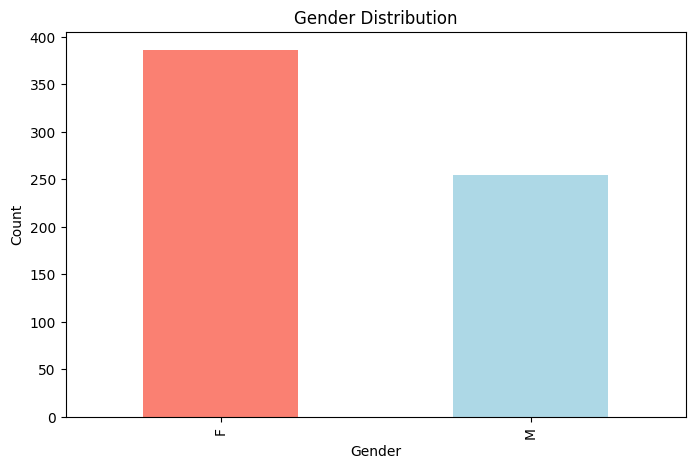

In [121]:
import matplotlib.pyplot as plt

gender_counts = analysis_info['Sex'].value_counts().sort_values(ascending=False)
plt.figure(figsize = (8, 5))
gender_counts.plot(kind='bar', color = ['salmon', 'lightblue'])
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

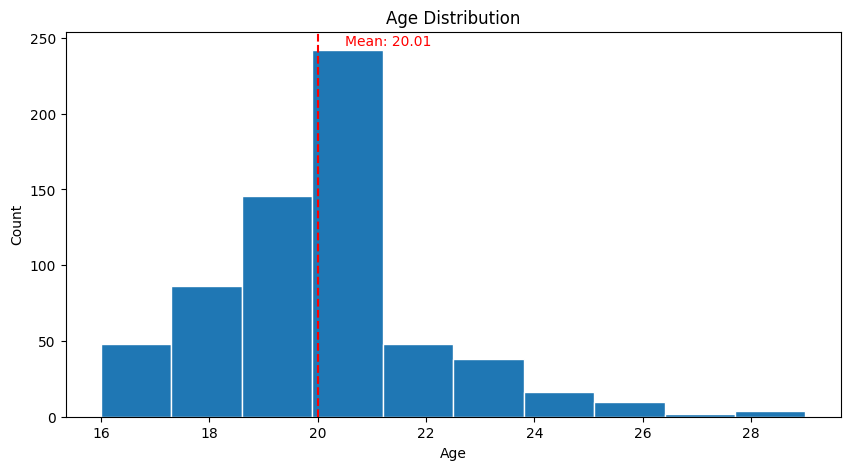

In [118]:
mean_age = np.mean(analysis_info['Age'])
plt.figure(figsize = (10, 5))
plt.hist(analysis_info['Age'], edgecolor="white")
plt.axvline(mean_age, linestyle = '--', color = 'red')
plt.text(mean_age + 0.5, 245, s=f"Mean: {round(mean_age, 2)}", color='red')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

In [104]:
country_counts = analysis_info['Country'].value_counts().sort_values(ascending=False)
country_counts

,count
Country,
CHN,80
JPN,80
TWN,80
KOR,80
THA,60
IDN,60
HKG,60
PHL,60
PAK,40


CHN - China

HKG - Hong Kong

IDN - Indonesia;

JPN - Japan;

KOR - Korea;

PAK - Pakistan;

PHL - Philippines;

SIN - Singapore;

MYS - Malaysia;

THA - Thailand;

TWN - Taiwan;

ENS - English native speakers

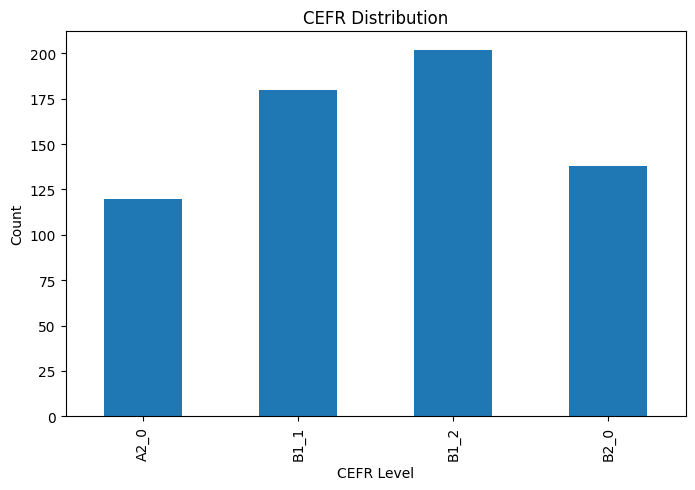

In [119]:
cefr_counts = analysis_info['CEFR'].value_counts()
desired_order = ['A2_0', 'B1_1', 'B1_2', 'B2_0']
cefr_counts = cefr_counts.reindex(desired_order)
plt.figure(figsize = (8, 5))
cefr_counts.plot(kind='bar')
plt.xlabel('CEFR Level')
plt.ylabel('Count')
plt.title('CEFR Distribution')
plt.show()

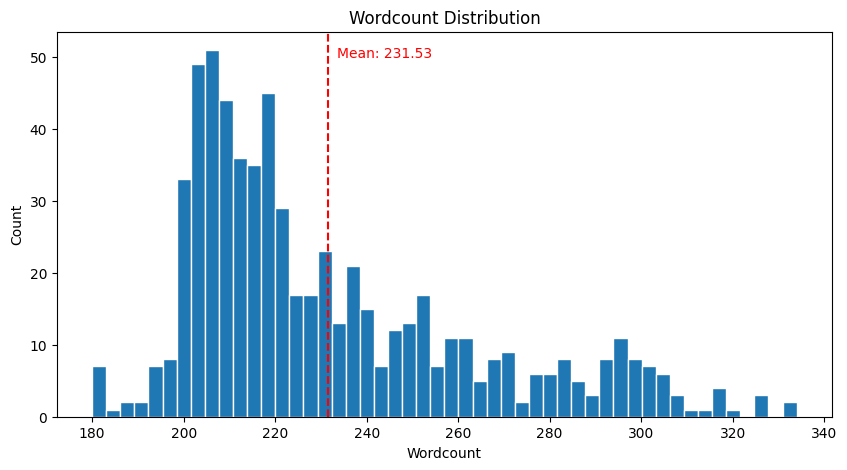

In [99]:
import numpy as np

mean_tokens = np.mean(analysis_info['Tokens'])
plt.figure(figsize = (10, 5))
plt.hist(analysis_info['Tokens'], bins = 50, edgecolor="white")
plt.axvline(mean_tokens, linestyle = '--', color = 'red')
plt.text(mean_tokens + 2, 50, s=f"Mean: {round(mean_tokens, 2)}", color='red')
plt.xlabel('Wordcount')
plt.ylabel('Count')
plt.title('Wordcount Distribution')
plt.show()

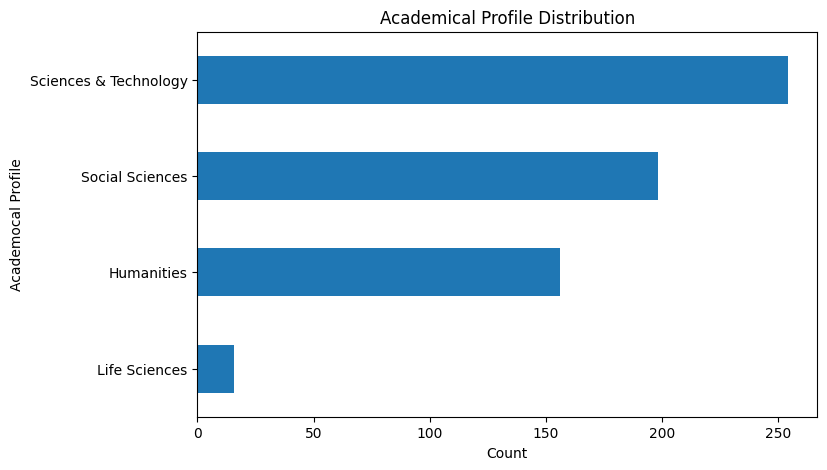

In [114]:
plt.figure(figsize = (8, 5))
profile_counts = analysis_info['Acad. Genre'].value_counts(ascending=True)
profile_counts.plot(kind='barh')
plt.ylabel('Academocal Profile')
plt.xlabel('Count')
plt.title('Academical Profile Distribution')
plt.show()